## Adjust Contrast and Brightness


we commonly used point processes are multiplication and addition with a constant:

    g(x)=αf(x)+β
    The parameters α>0 and β are often called the gain and bias parameters; sometimes these parameters are said to control contrast and brightness respectively.

    You can think of f(x) as the source image pixels and g(x) as the output image pixels. Then, more conveniently we can write the expression as:

    g(i,j)=α⋅f(i,j)+β

    where i and j indicates that the pixel is located in the i-th row and j-th column.
    
    long way:
    for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        for c in range(image.shape[2]):
            new_image[y,x,c] = np.clip(alpha*image[y,x,c] + beta, 0, 255)
            
 You can find more information here: https://docs.opencv.org/3.4/d3/dc1/tutorial_basic_linear_transform.html
 
 
 ### Task 1: Please change the brighness and the contrast of an image
 
 Find values to display vessel structures in image CONTRAST_1_CT.tif
 
by using 
            
            OPtion 1
            
            img = cv2.imread([image],cv2.IMREAD_UNCHANGED)
            new_image = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
            
            Option 2
            alpha 1  beta 0      --> no change  
            0 < alpha < 1        --> lower contrast  
            alpha > 1            --> higher contrast  
            -127 < beta < +127   --> good range for brightness values
            import cv2
            img = cv2.imread('input.png')
            # call addWeighted function. use beta = 0 to effectively only operate one one image
            new_image = cv2.addWeighted( img, contrast, img, 0, brightness)
            output = cv2.addWeighted
            
            ....


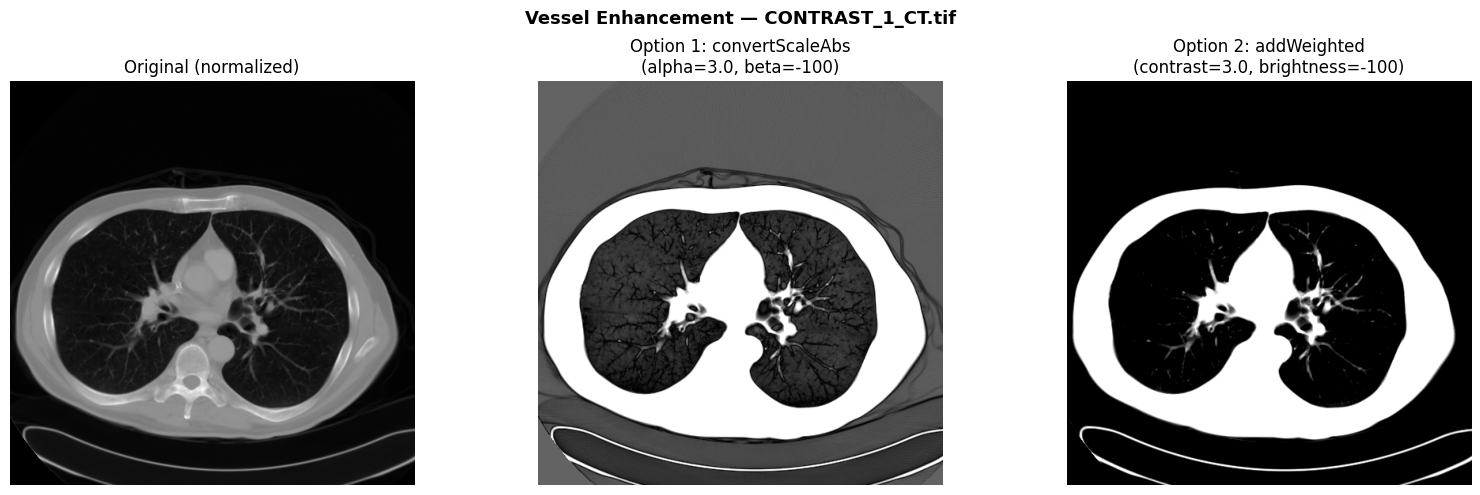

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tifffile

# ── Load CT image ─────────────────────────────────────────────────
ct_raw = tifffile.imread('CONTRAST_1_CT.tif')
# Normalize to uint8 first (required for cv2 functions)
img = ((ct_raw - ct_raw.min()) / (ct_raw.max() - ct_raw.min()) * 255).astype(np.uint8)

# ── Option 1: convertScaleAbs ─────────────────────────────────────
alpha = 3.0   # high contrast to reveal vessels
beta  = -100  # reduce brightness to darken background
option1 = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

# ── Option 2: addWeighted ─────────────────────────────────────────
contrast   = 3.0
brightness = -100
option2 = cv2.addWeighted(img, contrast, img, 0, brightness)

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Vessel Enhancement — CONTRAST_1_CT.tif', fontsize=13, fontweight='bold')

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (normalized)')
axes[0].axis('off')

axes[1].imshow(option1, cmap='gray')
axes[1].set_title(f'Option 1: convertScaleAbs\n(alpha={alpha}, beta={beta})')
axes[1].axis('off')

axes[2].imshow(option2, cmap='gray')
axes[2].set_title(f'Option 2: addWeighted\n(contrast={contrast}, brightness={brightness})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Contrast stretching
 use this image 'contrast_stretching.png'.
        
        b = im.max() 
        a = im.min() 
        # Converting im1 to float. 
        c = im.astype(float) 
        # Contrast stretching transformation. 
        im1 = 255.0*(c-a)/(b-a) 
        
        What happens afterwards with the image?


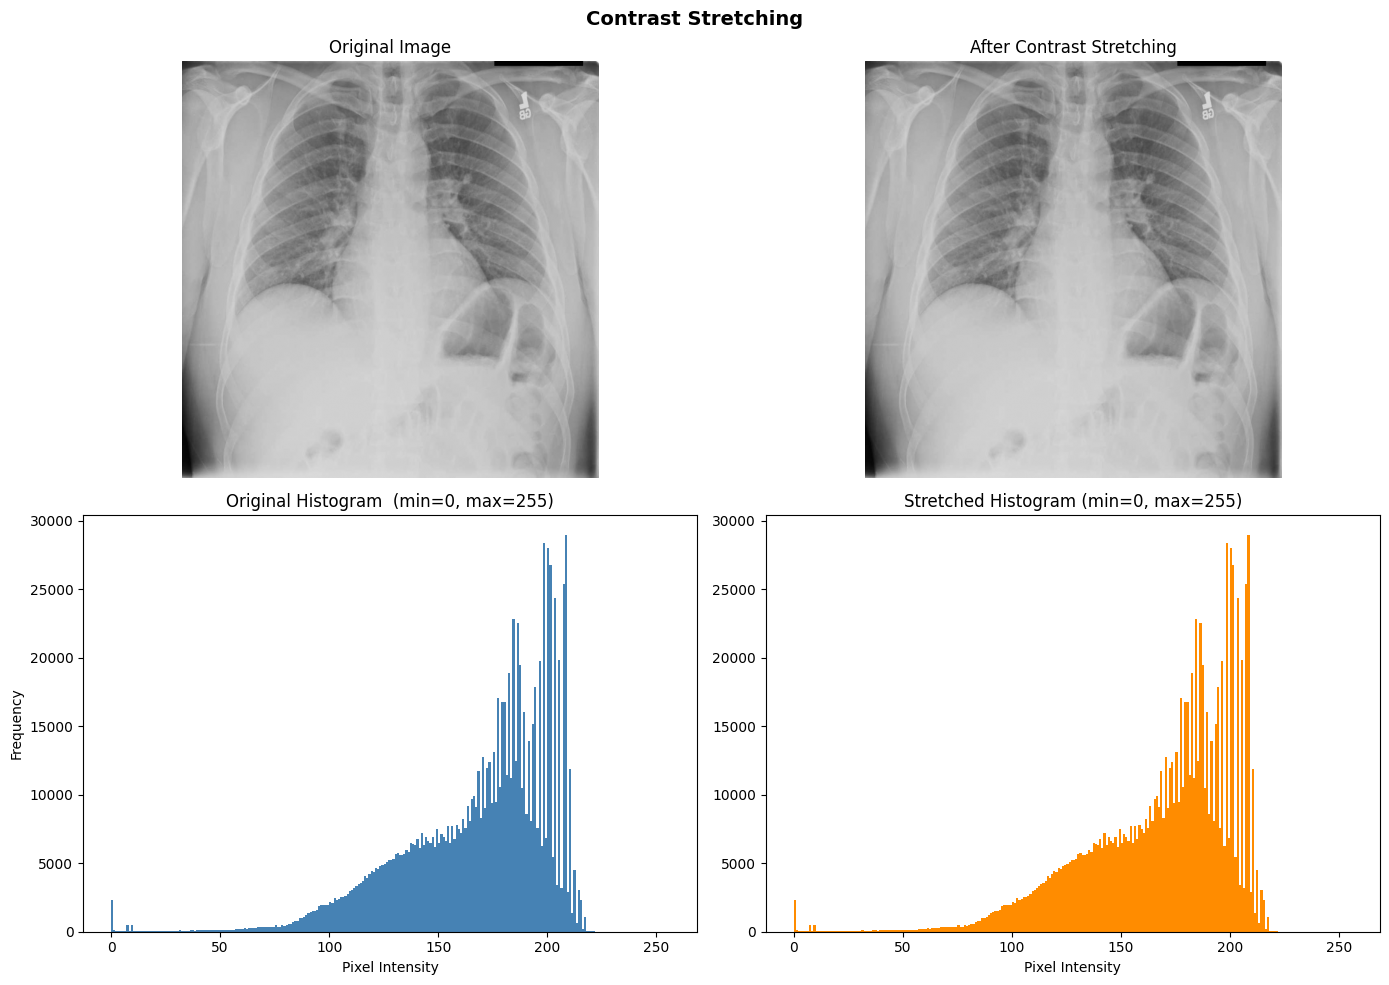

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

im = cv2.imread('contrast_stretching.png', cv2.IMREAD_GRAYSCALE)

# Maps the pixel range [min, max] to the full range [0, 255]
a = im.min()       
b = im.max()       
c = im.astype(float)  

im1 = 255.0 * (c - a) / (b - a)
im1 = np.clip(im1, 0, 255).astype(np.uint8)

#Plotting and Histogram

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(im, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(im1, cmap='gray')
axes[0, 1].set_title('After Contrast Stretching')
axes[0, 1].axis('off')

axes[1, 0].hist(im.flatten(), bins=256, range=[0, 256], color='steelblue')
axes[1, 0].set_title(f'Original Histogram  (min={a}, max={b})')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(im1.flatten(), bins=256, range=[0, 256], color='darkorange')
axes[1, 1].set_title('Stretched Histogram (min=0, max=255)')
axes[1, 1].set_xlabel('Pixel Intensity')

plt.suptitle('Contrast Stretching', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## What happens after contrast stretching?

Contrast stretching remaps pixel values so the darkest pixel becomes 0 
and the brightest becomes 255 — essentially stretching the histogram to 
cover the full intensity range [0, 255].

In this case, nothing visually changes. That's not a bug — it's because 
the original image already uses the full range (min=0, max=255). 
There's simply nothing left to stretch.

# Equalization


Equalize both images.'contrast_stretching.png'; CONTRAST_1_CT.tif
What do you see? Plot the histograms and CDF.

You can use: 
        
        img =  cv2.imread('',0)
        equ = cv2.equalizeHist(img)
        res = np.hstack((img,equ)) #stacking images side-by-side

        or
        
        hist,bins = np.histogram(img.flatten(),256,[0,256])
        cdf = hist.cumsum()
        cdf_m = np.ma.masked_equal(cdf,0)
        cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())
        cdf = np.ma.filled(cdf_m,0).astype('uint8')
        img2 = cdf[img]



to plot cdf:
        
        hist,bins = np.histogram(img.flatten(),256,[0,256])
        cdf = hist.cumsum()
        cdf_normalized = cdf * hist.max()/ cdf.max()

        plt.plot(cdf_normalized, color = 'b')
        plt.hist(img.flatten(),256,[0,256], color = 'r')
        
        plt.xlim([0,256])
        plt.legend(('cdf','histogram'), loc = 'upper left')
        plt.show()


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tifffile

# Load png normally
img1 = cv2.imread('contrast_stretching.png', 0)

# Load CT tif — it's a float64 image in Hounsfield Units [-1024, 894]
# Normalize to uint8 [0, 255] for histogram equalization
ct_raw = tifffile.imread('CONTRAST_1_CT.tif')
ct_normalized = ((ct_raw - ct_raw.min()) / (ct_raw.max() - ct_raw.min()) * 255).astype(np.uint8)
img2 = ct_normalized

/tmp/ipykernel_10078/145050642.py:43: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[2, col].hist(img.flatten(), 256, [0, 256], color='steelblue', alpha=0.7, label='Histogram')
/tmp/ipykernel_10078/145050642.py:50: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[3, col].hist(equ.flatten(), 256, [0, 256], color='darkorange', alpha=0.7, label='Histogram')


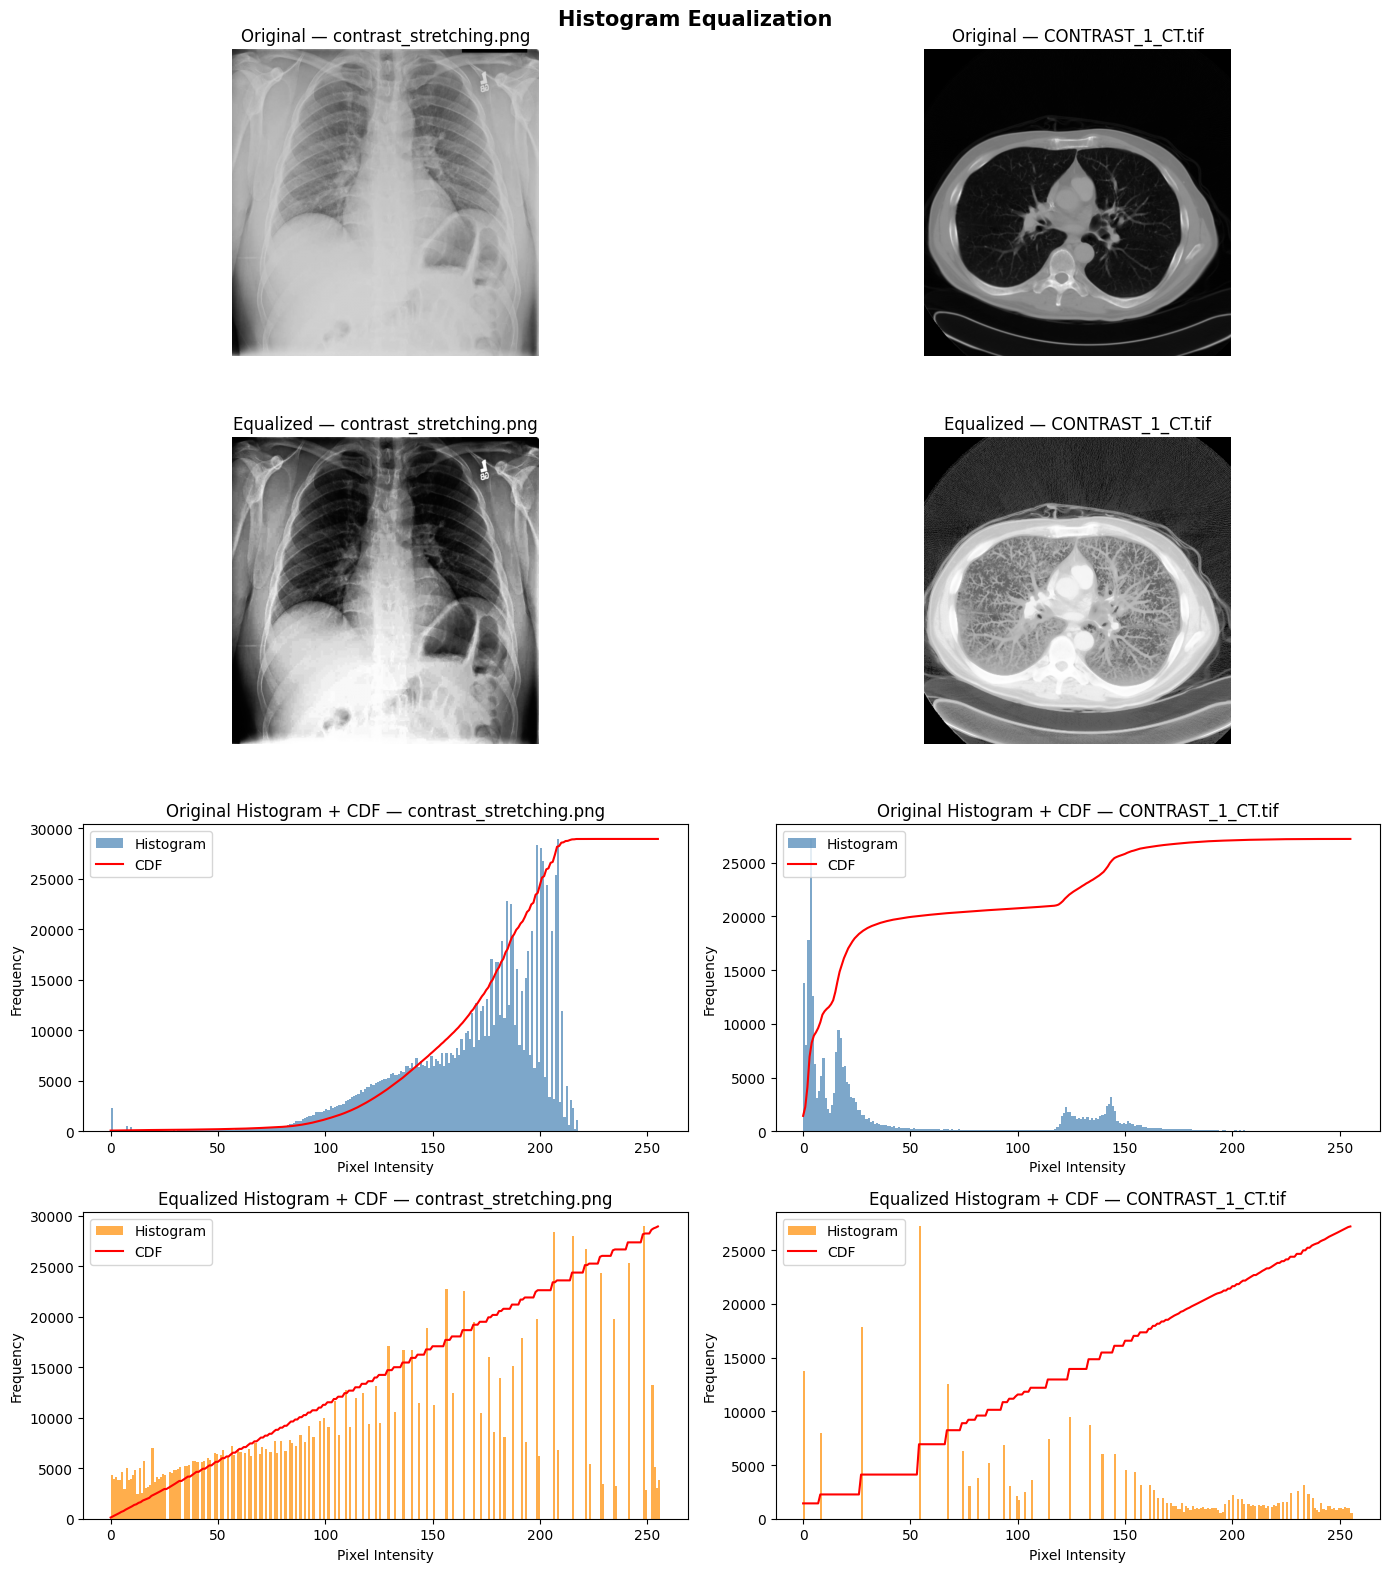

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tifffile

# Load png normally
img1 = cv2.imread('contrast_stretching.png', 0)

# Load CT tif — float64 Hounsfield Units, normalize to uint8
ct_raw = tifffile.imread('CONTRAST_1_CT.tif')
img2 = ((ct_raw - ct_raw.min()) / (ct_raw.max() - ct_raw.min()) * 255).astype(np.uint8)

# ── Apply histogram equalization ──────────────────────────────────
equ1 = cv2.equalizeHist(img1)
equ2 = cv2.equalizeHist(img2)

# ── Helper: compute histogram + CDF ───────────────────────────────
def get_hist_cdf(img):
    hist, bins = np.histogram(img.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    return hist, cdf_normalized

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

titles = ['contrast_stretching.png', 'CONTRAST_1_CT.tif']
originals = [img1, img2]
equalized = [equ1, equ2]

for col, (title, img, equ) in enumerate(zip(titles, originals, equalized)):
    hist_orig, cdf_orig = get_hist_cdf(img)
    hist_equ,  cdf_equ  = get_hist_cdf(equ)

    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f'Original — {title}')
    axes[0, col].axis('off')

    axes[1, col].imshow(equ, cmap='gray')
    axes[1, col].set_title(f'Equalized — {title}')
    axes[1, col].axis('off')

    axes[2, col].hist(img.flatten(), 256, [0, 256], color='steelblue', alpha=0.7, label='Histogram')
    axes[2, col].plot(cdf_orig, color='red', linewidth=1.5, label='CDF')
    axes[2, col].set_title(f'Original Histogram + CDF — {title}')
    axes[2, col].set_xlabel('Pixel Intensity')
    axes[2, col].set_ylabel('Frequency')
    axes[2, col].legend(loc='upper left')

    axes[3, col].hist(equ.flatten(), 256, [0, 256], color='darkorange', alpha=0.7, label='Histogram')
    axes[3, col].plot(cdf_equ, color='red', linewidth=1.5, label='CDF')
    axes[3, col].set_title(f'Equalized Histogram + CDF — {title}')
    axes[3, col].set_xlabel('Pixel Intensity')
    axes[3, col].set_ylabel('Frequency')
    axes[3, col].legend(loc='upper left')

plt.suptitle('Histogram Equalization', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## What do you see?

**Chest X-ray:** The original pixels cluster between 150–220 (mostly bright).
After equalization, intensity spreads across the full range — lung structures
become clearer, but some regions look over-enhanced.

**CT scan:** A big spike near 0 (air/background) dominates the original histogram.
Equalization pushes intensities apart, revealing vessels and tissue that were
barely visible before.

**Bottom line:** Global equalization is powerful but blunt — it treats the
entire image the same way. That's exactly the problem CLAHE solves.

# CLAHE (Contrastive Limited Adaptive Equalization)

Use CLAHE for the image  'contrast_stretching.png'. What happens? Save the image with the best contrast: best_contrast.png

        #clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))# code loops through each element in the PDF, and determines whether or not that element of the PDF is greater than the clipLimit
        cl1 = clahe.apply(img)

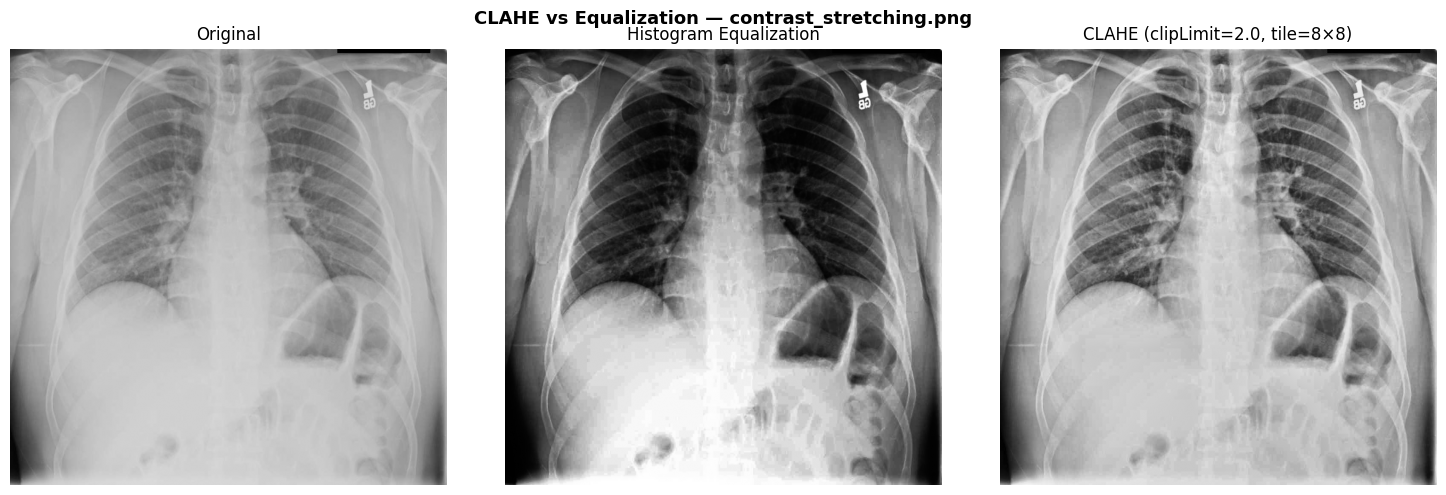

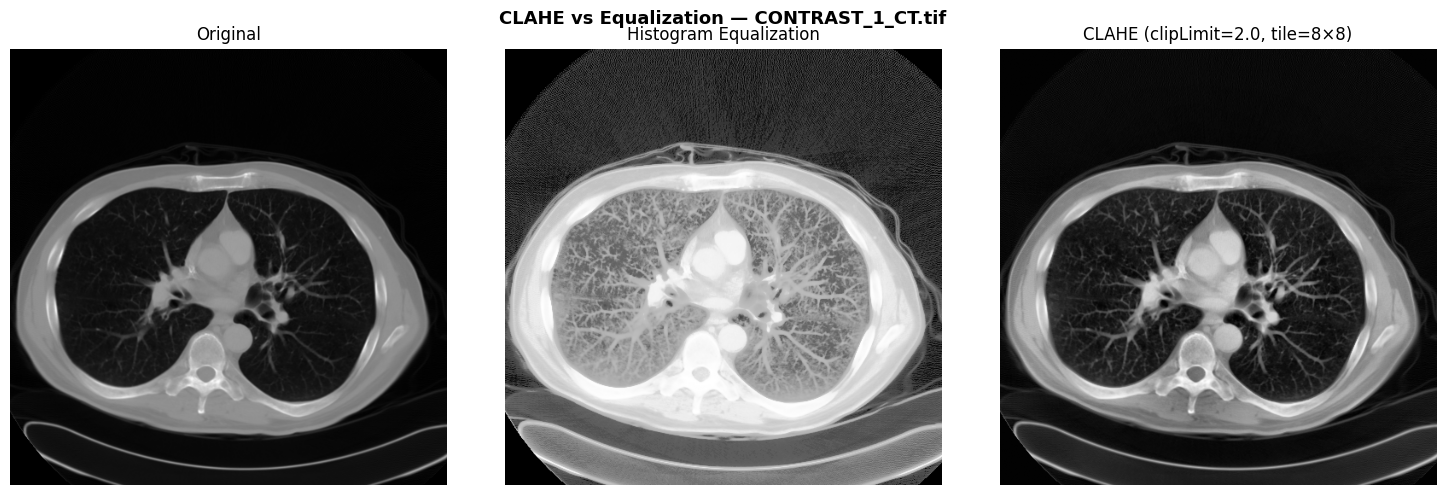

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tifffile

# ── Load images ───────────────────────────────────────────────────
img1 = cv2.imread('contrast_stretching.png', 0)

ct_raw = tifffile.imread('CONTRAST_1_CT.tif')
img2 = ((ct_raw - ct_raw.min()) / (ct_raw.max() - ct_raw.min()) * 255).astype(np.uint8)

# ── Apply equalization and CLAHE to both ──────────────────────────
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

equ1  = cv2.equalizeHist(img1)
cl1   = clahe.apply(img1)

equ2  = cv2.equalizeHist(img2)
cl2   = clahe.apply(img2)

# Save best contrast image
cv2.imwrite('best_contrast.png', cl1)

# ── Plot 3-way comparison for each image ─────────────────────────
for img, equ, cl, title in [
    (img1, equ1, cl1, 'contrast_stretching.png'),
    (img2, equ2, cl2, 'CONTRAST_1_CT.tif')
]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'CLAHE vs Equalization — {title}', fontsize=13, fontweight='bold')

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(equ, cmap='gray')
    axes[1].set_title('Histogram Equalization')
    axes[1].axis('off')

    axes[2].imshow(cl, cmap='gray')
    axes[2].set_title('CLAHE (clipLimit=2.0, tile=8×8)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

## What happens with CLAHE?

Unlike global histogram equalization which processes the entire image at once,
CLAHE divides the image into small tiles (8×8 here) and equalizes each one
separately — then blends them to avoid harsh boundaries.

The `clipLimit` controls how aggressively contrast is enhanced. Values above
the clip limit are redistributed rather than amplified, which prevents the
noise over-amplification that plain equalization suffers from.

In both images, CLAHE produces a more natural-looking result — local details
are enhanced without the washed-out or artificially bright regions that
global equalization introduces. This makes it the preferred choice in
medical imaging.

`best_contrast.png` has been saved using the CLAHE result.

# Thresholding

Create a Mask for the lungs by using a threshold in image: best_contrast.png

You can Use: 
        
        t = [value]
        binary_mask = img < t

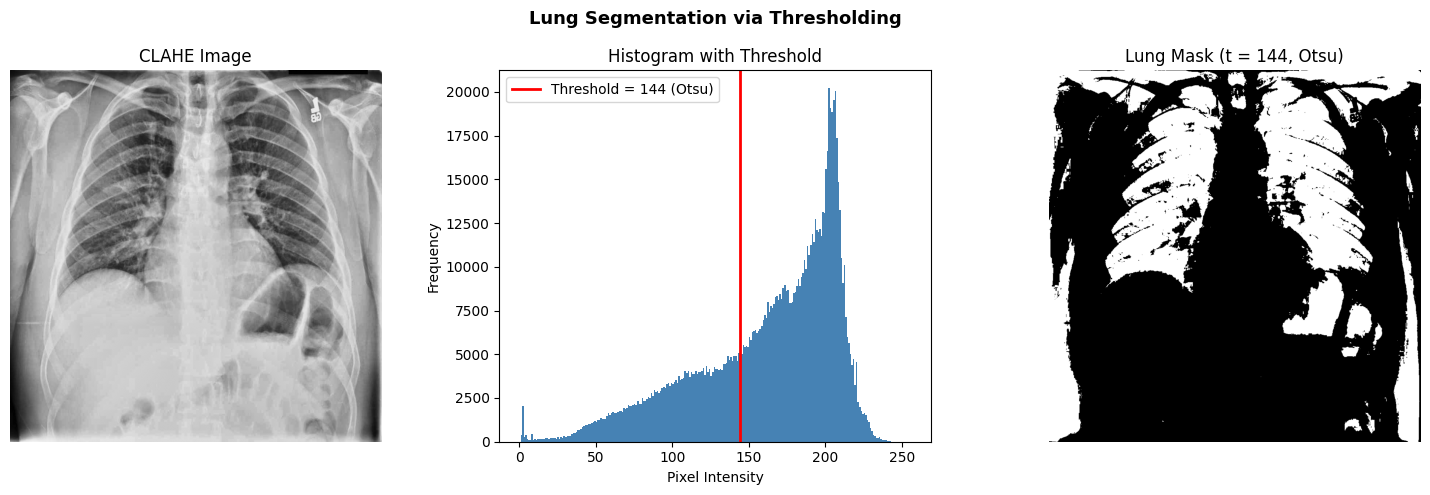

Otsu's optimal threshold: 144


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Load the CLAHE-enhanced image ─────────────────────────────────
img = cv2.imread('best_contrast.png', 0)

# ── Find threshold using Otsu's method ───────────────────────────
# Otsu automatically finds the optimal threshold by minimizing
# intra-class variance between foreground and background
otsu_val, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ── Apply threshold — lungs are dark so we keep pixels BELOW t ───
t = int(otsu_val)
binary_mask = (img < t).astype(np.uint8) * 255

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Lung Segmentation via Thresholding', fontsize=13, fontweight='bold')

axes[0].imshow(img, cmap='gray')
axes[0].set_title('CLAHE Image')
axes[0].axis('off')

axes[1].hist(img.flatten(), bins=256, range=[0, 256], color='steelblue')
axes[1].axvline(x=t, color='red', linewidth=2, label=f'Threshold = {t} (Otsu)')
axes[1].set_title('Histogram with Threshold')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')
axes[1].legend()

axes[2].imshow(binary_mask, cmap='gray')
axes[2].set_title(f'Lung Mask (t = {t}, Otsu)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Otsu's optimal threshold: {t}")


## Lung Mask via Thresholding

The threshold is selected automatically using **Otsu's method** (t=144),
which finds the optimal split between dark (lung/air) and bright (tissue/bone)
regions — removing the guesswork of picking a value manually.

The mask is imperfect, which is expected. Simple thresholding treats every
pixel independently with no spatial awareness, so overlapping intensity ranges
between lungs and other dark regions (like the background) cause misclassification.
In practice, more advanced segmentation methods are used for clinical applications.

## Image matching

Match the images contrast_stretching.png and best_contrast.png. What happens?

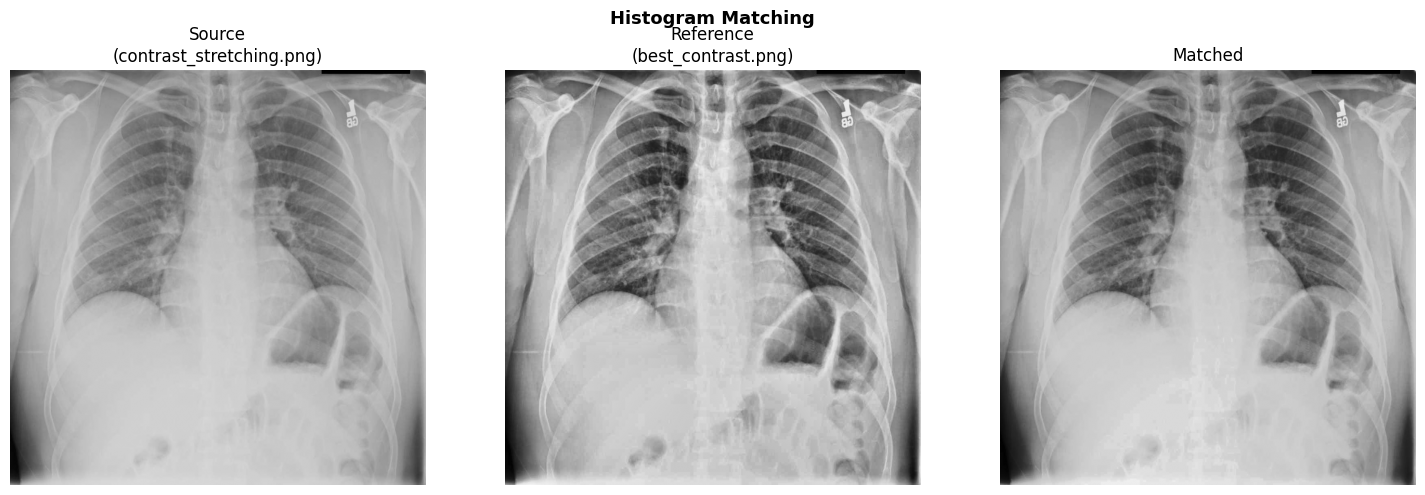

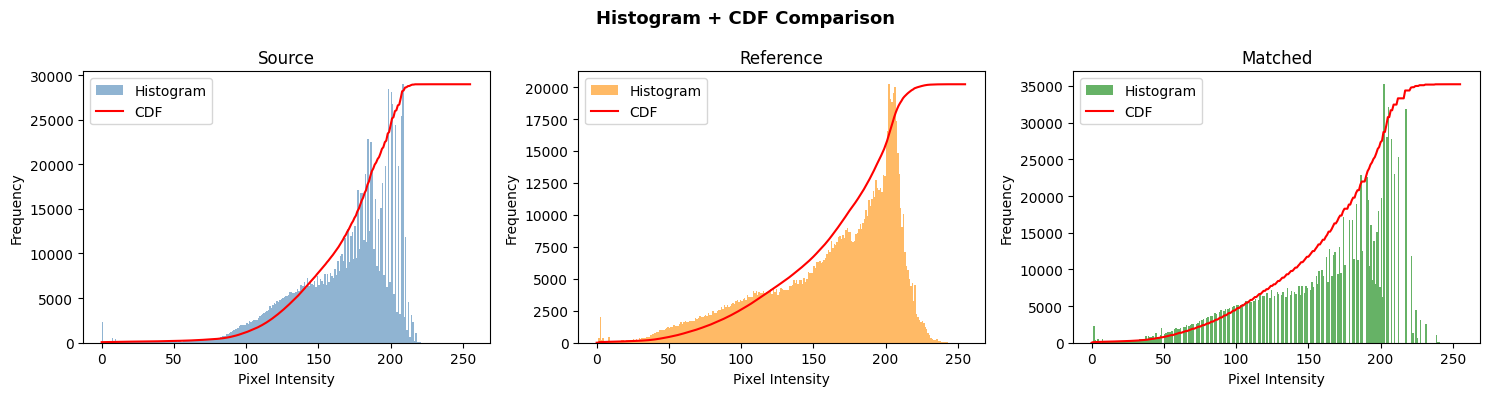

In [20]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure

# ── Load images ───────────────────────────────────────────────────
# Source: original chest X-ray
# Reference: CLAHE-enhanced version (best_contrast.png)
src = cv2.imread('contrast_stretching.png', 0)
ref = cv2.imread('best_contrast.png', 0)

# ── Perform histogram matching ────────────────────────────────────
# Matches the histogram of src to the histogram of ref
matched = exposure.match_histograms(src, ref)
matched = matched.astype(np.uint8)

# ── Helper: histogram + CDF ───────────────────────────────────────
def get_hist_cdf(img):
    hist, bins = np.histogram(img.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf / cdf.max()
    return hist, cdf_normalized

# ── Plot images ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Histogram Matching', fontsize=13, fontweight='bold')

for ax, img, title in zip(axes,
                           [src, ref, matched],
                           ['Source\n(contrast_stretching.png)',
                            'Reference\n(best_contrast.png)',
                            'Matched']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ── Plot histograms + CDFs ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Histogram + CDF Comparison', fontsize=13, fontweight='bold')

colors = ['steelblue', 'darkorange', 'green']
titles = ['Source', 'Reference', 'Matched']
images = [src, ref, matched]

for ax, img, title, color in zip(axes, images, titles, colors):
    hist, cdf = get_hist_cdf(img)
    ax.hist(img.flatten(), bins=256, range=[0, 256],
            color=color, alpha=0.6, label='Histogram')
    ax.plot(cdf * hist.max(), color='red',
            linewidth=1.5, label='CDF')
    ax.set_title(title)
    ax.set_xlabel('Pixel Intensity')
    ax.set_ylabel('Frequency')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()